In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pydrake.all import (
    DiagramBuilder,
    LinearQuadraticRegulator,
    LinearSystem,
    LogVectorOutput,
    PiecewisePolynomial,
    Simulator,
    TrajectorySource,
)
from pydrake.solvers import MathematicalProgram, Solve

np.random.seed(0)

# Linear System Identification

In this notebook, you will test different objective functions in linear system identification. Consider a discrete-time linear system of the form

$$x[n+1] = Ax[n]+Bu[n]$$
where $x[n]\in\mathbf{R}^p$ and $u[n]\in\mathbf{R}^q$ are state and control at step $n$.
The system matrix $A\in\mathbf{R}^{p\times p}$ and $B\in\mathbf{R}^{p\times q}$ are unknown parameters of the model, and your task is to identify the parameters given a simulated trajectory.

Let's first define a test system:

In [2]:
A = np.array(
    [
        [0.8, -0.1, 0.0, 0.0],
        [0.0, 0.2, 0.0, 0.1],
        [0.0, -0.1, 1.0001, 0.0],
        [0.0, 0.2, 0.0, 0.1],
    ]
)

B = np.array([[0.0], [-0.02], [0.01], [-0.02]])
C = np.identity(4)
D = np.zeros((4, 1))

Let's run a simulation to obtain the trajectory data. We add noise to the state representing measurement noise.

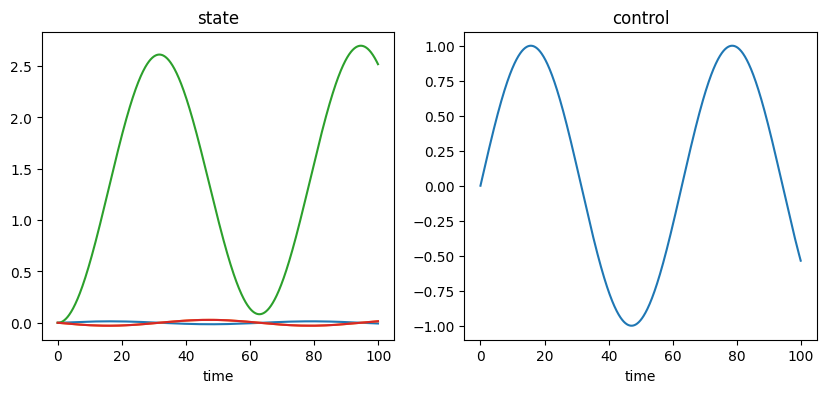

In [3]:
def generate_data(A, B, C, D, noise_level=1e-5):
    # Define a Linear system
    sys = LinearSystem(A, B, C, D, time_period=0.1)

    ts = np.arange(0, 100, 0.1)
    utraj = PiecewisePolynomial.CubicShapePreserving(
        ts, np.sin(0.1 * ts).reshape((1, -1))
    )

    builder = DiagramBuilder()
    plant = builder.AddSystem(sys)

    usys = builder.AddSystem(TrajectorySource(utraj))
    builder.Connect(usys.get_output_port(), plant.get_input_port())

    logger = LogVectorOutput(plant.get_output_port(), builder)
    diagram = builder.Build()

    simulator = Simulator(diagram)
    simulator.AdvanceTo(ts[-1])

    log = logger.FindLog(simulator.get_context())
    t = log.sample_times()
    U = utraj.vector_values(log.sample_times())
    X = log.data()
    X = X + np.random.normal(size=X.shape) * noise_level

    return t, U, X


t, U, X = generate_data(A, B, C, D)


fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(t, X.T)
ax[1].plot(t, U.T)
ax[0].set_title("state")
ax[1].set_title("control")
ax[0].set_xlabel("time")
ax[1].set_xlabel("time")
plt.show()

The output of the simulation gives the data matrices in the following format:

$$X=\begin{bmatrix} \lvert && \lvert && && \lvert \\ x[0] && x[1] && \dots && x[N] \\ \lvert && \lvert && && \lvert \end{bmatrix}$$


$$U=\begin{bmatrix} \lvert && \lvert && && \lvert \\ u[0] && u[1] && \dots && u[N] \\ \lvert && \lvert && && \lvert \end{bmatrix}.$$

Using the simulated data, you will implement regression algorithms to identify the system model.

(a) Identify the model by solving the following optimization problem: 

$$\min_{A, B}\sum_{n=0}^{N-1}\lVert x[n+1] - Ax[n] -Bu[n] \rVert_2^2$$

The function should output the matrices $A$ and $B$ that are the solutions to the above optimization problem.

In [4]:
def sysid_2norm(X, U):
    n = X.shape[0]
    m = U.shape[0]
    A = np.zeros((n, n))
    B = np.zeros((n, m))
    ######### Put your Solution here ############
    # Least squares: find [A B] minimizing sum_n || x[n+1] - A x[n] - B u[n] ||_2^2.
    # Stack the regressors into Z = [[x[0] ... x[N-1]], [u[0] ... u[N-1]]] and the
    # targets into Y = [x[1] ... x[N]], then solve the linear least-squares problem
    # Theta @ Z ~= Y for Theta = [A B].  We use lstsq (numerically stable) instead of
    # forming the normal equations explicitly.
    Z = np.vstack([X[:, :-1], U[:, :-1]])  # (n + m) x N
    Y = X[:, 1:]  # n x N
    Theta = np.linalg.lstsq(Z.T, Y.T, rcond=None)[0].T  # n x (n + m)
    A = Theta[:, :n]
    B = Theta[:, n:]
    ##############################################
    return A, B


Ahat_2norm, Bhat_2norm = sysid_2norm(X, U)

print("A = ")
print(A)
print("Â = ")
print(Ahat_2norm)
print("")
print("B = ")
print(B)
print("B̂ = ")
print(Bhat_2norm)
print("")

res = Ahat_2norm @ X[:, :-1] + Bhat_2norm @ U[:, :-1] - X[:, 1:]
print(f"residual (2-norm): {np.sum(res**2)}")
print(f"residual (inf-norm): {np.sum(np.max(np.abs(res), axis = 0))}")
print(f"residual (1-norm): {np.sum(np.abs(res))}")

A = 
[[ 0.8    -0.1     0.      0.    ]
 [ 0.      0.2     0.      0.1   ]
 [ 0.     -0.1     1.0001  0.    ]
 [ 0.      0.2     0.      0.1   ]]
Â = 
[[ 7.57168751e-01 -6.75260137e-02  3.05126452e-08 -1.27862137e-01]
 [-2.02884439e-02  8.59044934e-02  1.13813603e-07  1.69718931e-01]
 [ 1.01268545e-02 -2.77646916e-02  1.00009999e+00 -4.96232256e-02]
 [-3.64273692e-02  6.59807688e-02 -7.41259158e-10  1.52575342e-01]]

B = 
[[ 0.  ]
 [-0.02]
 [ 0.01]
 [-0.02]]
B̂ = 
[[-0.00211509]
 [-0.02097863]
 [ 0.01050172]
 [-0.02180848]]

residual (2-norm): 5.312848278421001e-07
residual (inf-norm): 0.016881885276378794
residual (1-norm): 0.03672343095062146


(b) Identify the model by solving the following optimization problem: 

$$\min_{A, B}\sum_{n=0}^{N-1}\lVert x[n+1] - Ax[n] -Bu[n] \rVert_{\infty}.$$

where $L\infty$ norm of a vector is defined as

$$\lVert x \rVert_\infty = \max_{1\leq i\leq p}\lvert x_i\rvert.$$
Implement the following function that outputs the matrices $A$ and $B$ that are the solutions to the above optimization problem.


In [5]:
def sysid_infnorm(X, U):
    n = X.shape[0]
    m = U.shape[0]
    A = np.zeros((n, n))
    B = np.zeros((n, m))
    ######### Put your Solution here ############
    # Minimize sum_n || x[n+1] - A x[n] - B u[n] ||_inf.  For each time step introduce
    # a scalar s[n] that upper-bounds the infinity-norm of the residual, i.e.
    # -s[n] <= residual_i[n] <= s[n] for every state component i, and minimize sum_n s[n].
    Xd = X[:, :-1]
    Ud = U[:, :-1]
    Y = X[:, 1:]
    N = Y.shape[1]

    prog = MathematicalProgram()
    Avar = prog.NewContinuousVariables(n, n, "A")
    Bvar = prog.NewContinuousVariables(n, m, "B")
    s = prog.NewContinuousVariables(N, "s")

    residual = Avar @ Xd + Bvar @ Ud - Y  # (n x N) symbolic residual
    s_row = np.tile(s, (n, 1))  # broadcast the per-step bound over the n components
    # residual - s <= 0  and  residual + s >= 0  <=>  -s <= residual <= s
    prog.AddLinearConstraint(
        (residual - s_row).flatten(), np.full(n * N, -np.inf), np.zeros(n * N)
    )
    prog.AddLinearConstraint(
        (residual + s_row).flatten(), np.zeros(n * N), np.full(n * N, np.inf)
    )
    prog.AddLinearCost(np.sum(s))

    result = Solve(prog)
    assert result.is_success(), "infinity-norm sysid LP failed to solve"
    A = np.asarray(result.GetSolution(Avar)).reshape(n, n)
    B = np.asarray(result.GetSolution(Bvar)).reshape(n, m)
    obj_value = result.get_optimal_cost()

    ##############################################
    return A, B, obj_value


Ahat_infnorm, Bhat_infnorm, obj_infnorm = sysid_infnorm(X, U)

print("A = ")
print(A)
print("Â = ")
print(Ahat_infnorm)
print("")
print("B = ")
print(B)
print("B̂ = ")
print(Bhat_infnorm)
print("")

res = Ahat_infnorm @ X[:, :-1] + Bhat_infnorm @ U[:, :-1] - X[:, 1:]
print(f"residual (2-norm): {np.sum(res**2)}")
print(f"residual (inf-norm): {np.sum(np.max(np.abs(res), axis = 0))}")
print(f"residual (1-norm): {np.sum(np.abs(res))}")

A = 
[[ 0.8    -0.1     0.      0.    ]
 [ 0.      0.2     0.      0.1   ]
 [ 0.     -0.1     1.0001  0.    ]
 [ 0.      0.2     0.      0.1   ]]
Â = 
[[ 7.46085829e-01 -7.89137064e-02 -1.01438637e-08 -1.41849919e-01]
 [-5.20571486e-02  3.93006690e-03  1.32369313e-07  1.78676261e-01]
 [ 2.61273471e-02 -1.66627455e-02  1.00009977e+00 -2.67755971e-02]
 [-7.39603255e-02 -7.44745902e-03  7.17108418e-08  1.41051812e-01]]

B = 
[[ 0.  ]
 [-0.02]
 [ 0.01]
 [-0.02]]
B̂ = 
[[-0.00268203]
 [-0.02261168]
 [ 0.01124406]
 [-0.02370045]]

residual (2-norm): 5.373346950732532e-07
residual (inf-norm): 0.016859893071431924
residual (1-norm): 0.036824395757890004


(c) Identify the model by solving the following optimization problem: 

$$\min_{A, B}\sum_{n=0}^{N-1}\lVert x[n+1] - Ax[n] -Bu[n] \rVert_1.$$
where the $L1$ norm of a vector is defined as
$$\lVert x \rVert_1 = \sum_{i=1}^p \lvert x_i\rvert.$$
The function should output the matrices $A$ and $B$ that are the solutions to the above optimization problem.


In [6]:
def sysid_1norm(X, U):
    n = X.shape[0]
    m = U.shape[0]
    A = np.zeros((n, n))
    B = np.zeros((n, m))
    ######### Put your Solution here ############
    # Minimize sum_n || x[n+1] - A x[n] - B u[n] ||_1.  Introduce a slack t[i, n] for
    # every residual entry with t[i, n] >= |residual_i[n]| (encoded by the two linear
    # inequalities -t <= residual <= t) and minimize the sum of all slacks.
    Xd = X[:, :-1]
    Ud = U[:, :-1]
    Y = X[:, 1:]
    N = Y.shape[1]

    prog = MathematicalProgram()
    Avar = prog.NewContinuousVariables(n, n, "A")
    Bvar = prog.NewContinuousVariables(n, m, "B")
    T = prog.NewContinuousVariables(n, N, "t")

    residual = Avar @ Xd + Bvar @ Ud - Y  # (n x N) symbolic residual
    # residual - t <= 0  and  residual + t >= 0  <=>  -t <= residual <= t
    prog.AddLinearConstraint(
        (residual - T).flatten(), np.full(n * N, -np.inf), np.zeros(n * N)
    )
    prog.AddLinearConstraint(
        (residual + T).flatten(), np.zeros(n * N), np.full(n * N, np.inf)
    )
    prog.AddLinearCost(np.sum(T))

    result = Solve(prog)
    assert result.is_success(), "1-norm sysid LP failed to solve"
    A = np.asarray(result.GetSolution(Avar)).reshape(n, n)
    B = np.asarray(result.GetSolution(Bvar)).reshape(n, m)
    obj_value = result.get_optimal_cost()

    ##############################################
    return A, B, obj_value


Ahat_1norm, Bhat_1norm, obj_1norm = sysid_1norm(X, U)

print("A = ")
print(A)
print("Â = ")
print(Ahat_1norm)
print("")
print("B = ")
print(B)
print("B̂ = ")
print(Bhat_1norm)
print("")

res = Ahat_1norm @ X[:, :-1] + Bhat_1norm @ U[:, :-1] - X[:, 1:]
print(f"residual (2-norm): {np.sum(res**2)}")
print(f"residual (inf-norm): {np.sum(np.max(np.abs(res), axis = 0))}")
print(f"residual (1-norm): {np.sum(np.abs(res))}")

A = 
[[ 0.8    -0.1     0.      0.    ]
 [ 0.      0.2     0.      0.1   ]
 [ 0.     -0.1     1.0001  0.    ]
 [ 0.      0.2     0.      0.1   ]]
Â = 
[[ 7.33509513e-01 -1.29389430e-01 -1.10428804e-08 -1.18753241e-01]
 [-1.31077768e-02  1.15721469e-01  1.02250446e-07  1.56411829e-01]
 [ 1.09243761e-02 -4.89416442e-02  1.00009992e+00 -2.60288740e-02]
 [-6.04927869e-02  3.77943834e-02 -1.76002889e-07  1.24877087e-01]]

B = 
[[ 0.  ]
 [-0.02]
 [ 0.01]
 [-0.02]]
B̂ = 
[[-0.00328562]
 [-0.02060931]
 [ 0.01055994]
 [-0.0230621 ]]

residual (2-norm): 5.342582194157453e-07
residual (inf-norm): 0.01689534751910545
residual (1-norm): 0.03668334707630851


Let's try LQR controller with the identified models. Using the estimated parameters, $\hat{A}$ and $\hat{B}$, we solve discrete-time LQR. The controller is used to stabilize the original linear system defined by the parameters, $A$ and $B$. If the estimate was accurate, we expect the controller to work well for the original system.

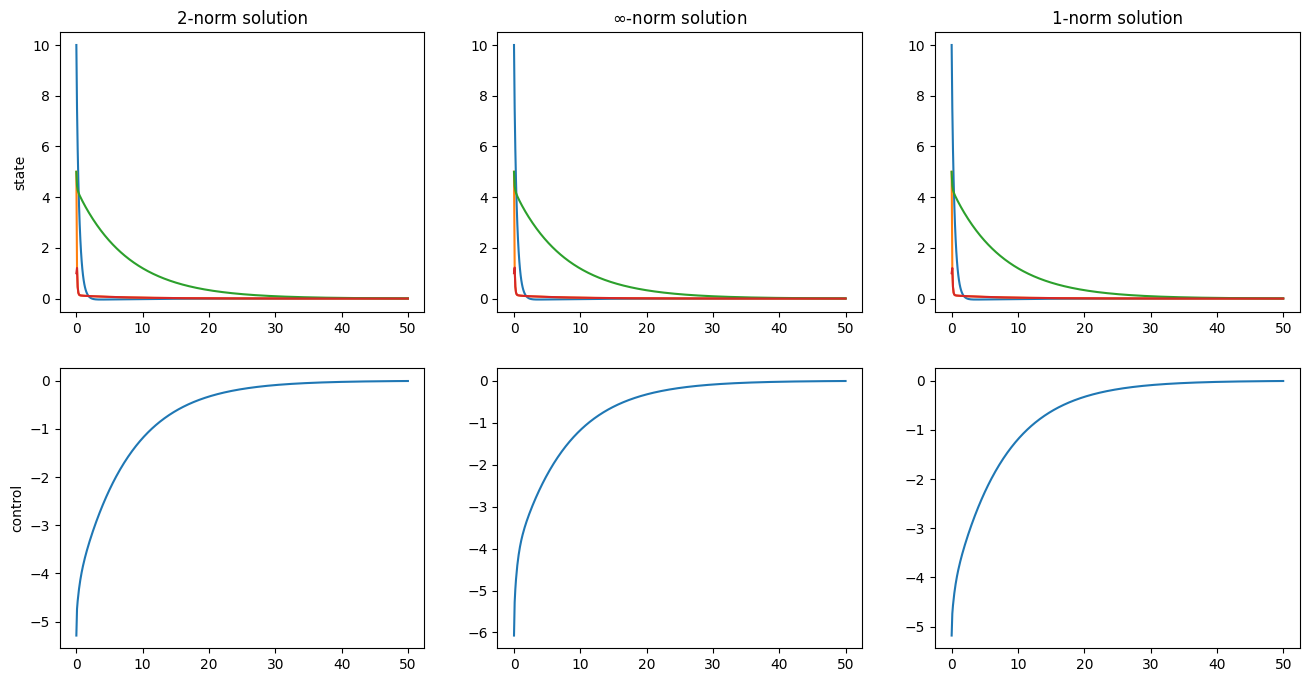

In [7]:
def test_LQR(A_hat, B_hat, Q=None, R=None):
    Q = np.identity(A.shape[0]) if Q is None else Q
    R = np.identity(B.shape[1]) if R is None else R

    # Define a Linear system
    sys = LinearSystem(A, B, C, D, time_period=0.1)
    sys_hat = LinearSystem(A_hat, B_hat, C, D, time_period=0.1)

    builder = DiagramBuilder()
    plant = builder.AddSystem(sys)

    controller = builder.AddSystem(LinearQuadraticRegulator(sys_hat, Q, R))

    builder.Connect(controller.get_output_port(), plant.get_input_port())
    builder.Connect(plant.get_output_port(), controller.get_input_port())

    logger = LogVectorOutput(plant.get_output_port(), builder)
    logger_ctrl = LogVectorOutput(controller.get_output_port(), builder)

    diagram = builder.Build()
    simulator = Simulator(diagram)
    context = simulator.get_mutable_context()
    context.SetDiscreteState(0, [10.0, 5.0, 5.0, 1.0])

    simulator.AdvanceTo(50)

    log = logger.FindLog(context)
    log_ctrl = logger_ctrl.FindLog(context)
    t = log.sample_times()
    U = log_ctrl.data()
    X = log.data()

    return t, U, X


t, U_2norm, X_2norm = test_LQR(Ahat_2norm, Bhat_2norm)
t, U_infnorm, X_infnorm = test_LQR(Ahat_infnorm, Bhat_infnorm)
t, U_1norm, X_1norm = test_LQR(Ahat_1norm, Bhat_1norm)

fig, ax = plt.subplots(2, 3, figsize=(16, 8))
ax[0, 0].plot(t, X_2norm.T)
ax[1, 0].plot(t, U_2norm.T)
ax[0, 1].plot(t, X_infnorm.T)
ax[1, 1].plot(t, U_infnorm.T)
ax[0, 2].plot(t, X_1norm.T)
ax[1, 2].plot(t, U_1norm.T)
ax[0, 0].set_ylabel("state")
ax[1, 0].set_ylabel("control")
ax[0, 0].set_title("2-norm solution")
ax[0, 1].set_title("$\infty$-norm solution")
ax[0, 2].set_title("1-norm solution")
plt.show()

You can also test the model with increased noise in the data. You can play around with different values of 'noise_level' to vary the intensity of the noise in the measurement.

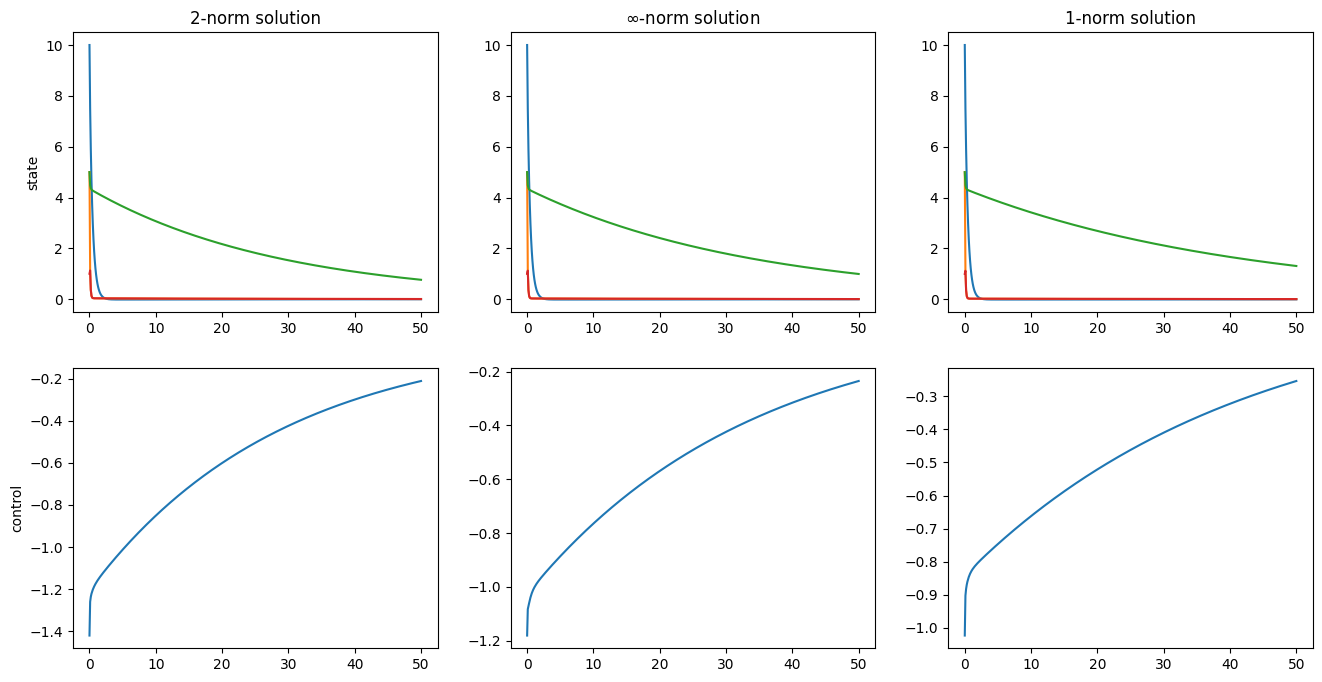

In [8]:
t, U_noisy, X_noisy = generate_data(A, B, C, D, noise_level=0.5)

Ahat_noisy_2norm, Bhat_noisy_2norm = sysid_2norm(X_noisy, U_noisy)
t, U_2norm, X_2norm = test_LQR(Ahat_noisy_2norm, Bhat_noisy_2norm)

Ahat_noisy_infnorm, Bhat_noisy_infnorm, obj_infnorm_noisy = sysid_infnorm(
    X_noisy, U_noisy
)
t, U_infnorm, X_infnorm = test_LQR(Ahat_noisy_infnorm, Bhat_noisy_infnorm)

Ahat_noisy_1norm, Bhat_noisy_1norm, obj_1norm_noisy = sysid_1norm(X_noisy, U_noisy)
t, U_1norm, X_1norm = test_LQR(Ahat_noisy_1norm, Bhat_noisy_1norm)

fig, ax = plt.subplots(2, 3, figsize=(16, 8))
ax[0, 0].plot(t, X_2norm.T)
ax[1, 0].plot(t, U_2norm.T)
ax[0, 1].plot(t, X_infnorm.T)
ax[1, 1].plot(t, U_infnorm.T)
ax[0, 2].plot(t, X_1norm.T)
ax[1, 2].plot(t, U_1norm.T)
ax[0, 0].set_ylabel("state")
ax[1, 0].set_ylabel("control")
ax[0, 0].set_title("2-norm solution")
ax[0, 1].set_title("$\infty$-norm solution")
ax[0, 2].set_title("1-norm solution")
plt.show()

## Autograding
You can check your work by running the following cell:

In [9]:
from underactuated.exercises.grader import Grader
from underactuated.exercises.sysid.test_linear_sysid import TestLinearSysid

Grader.grade_output([TestLinearSysid], [locals()], "results.json")
Grader.print_test_results("results.json")

Total score is 9/9.

Score for Test L1 regression is 3/3.

Score for Test L2 regression is 3/3.

Score for Test L infinite regression is 3/3.
